In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [2]:
# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.5     # Total time


In [3]:

traj = EMRIInspiral(func=KerrEccEqFlux) #theres npoints flag here
amp = AmpInterpKerrEccEq(force_backend="cuda12x") # default lmax=10, nmax=55
interpolate_mode_sum = InterpolatedModeSum(force_backend="cuda12x")
ylm_gen = GetYlms(include_minus_m=False, force_backend="cuda12x")
gwf = GWfuncs.GravWaveAnalysis(T=T, dt=dt)


In [35]:
# Source parameters 
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 15 #11.7 if u want to plunge, original = 15
e0 = 0.4
xI0 = 1.0
dist = 0.25  # Gpc

# faceon 0 deg 
# qS = np.pi
# phiS = 0
# qK = 0
# phiK = 0


#FACEON180deg
# qS = np.pi/2
# phiS = 0
# qK = np.pi/2
# phiK = 0

# inbetween
qS = 0.5   
phiS = 1.0        
qK = 1.0      
phiK = 1.0 + np.pi/3  

#edge on 
# qS = np.pi/2
# phiS = 0
# qK = 0
# phiK = 0


Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

In [36]:
def get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

In [37]:
theta, phi = get_viewing_angles(qS, phiS, qK, phiK)
theta, phi

(2.3129424767905524, -1.5707963267948966)

In [38]:
theta*180/np.pi

132.521842176634

In [39]:
N_traj = int(1e4)
delta_T = T * YRSID_SI / N_traj 
delta_T

1577.9074881772797

In [40]:
(t, p, e, x, Phi_phi, Phi_theta, Phi_r) = traj(m1, m2, a, p0, e0, xI0, T=T, dt=delta_T, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, upsample=True)


In [41]:
teuk_modes = amp(a, p, e, x)
ylms = ylm_gen(amp.unique_l, amp.unique_m, theta, phi).copy()[amp.inverse_lm]

In [42]:
ylms

array([ 0.20982341+0.00000000e+00j,  0.20982341+0.00000000e+00j,
        0.20982341+0.00000000e+00j, ..., -0.10956013+6.70862332e-17j,
       -0.10956013+6.70862332e-17j, -0.10956013+6.70862332e-17j])

In [43]:
from few.utils.geodesic import get_fundamental_frequencies
OmegaPhi, _, OmegaR = get_fundamental_frequencies(a, p, e, x)
gw_frequencies_per_mode = []
for idx in range(len(amp.l_arr)):
    m = amp.m_arr[idx]
    n = amp.n_arr[idx]

    m = m.get() if isinstance(m, cp.ndarray) else m
    n = n.get() if isinstance(n, cp.ndarray) else n

    # Calculate GW frequencies (dimensionless)
    f_gw = m * OmegaPhi + n * OmegaR
    gw_frequencies_per_mode.append(f_gw)


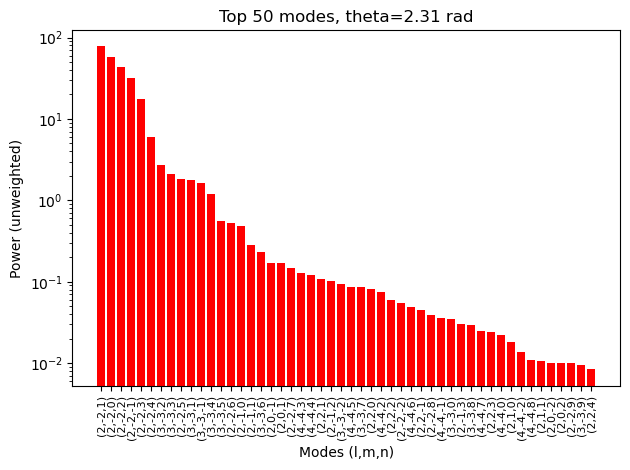

In [44]:
# Get WEIGHTED power
m0mask = amp.m_arr_no_mask != 0
# total_power = gwf.calc_power(teuk_modes, ylms, m0mask, m1=m1, m2=m2, gw_freqs=gw_frequencies_per_mode)
total_power = gwf.calc_power(teuk_modes, ylms, m0mask)


# Get mode labels
mode_labels = [f"({l},{m},{n})" for l,m,n in zip(amp.l_arr, amp.m_arr, amp.n_arr)]

# Bar plot of modes vs approx inner product for top M modes 
M_mode = 50
ma = list(zip(mode_labels, total_power)) 
# Sort by power and pick top 100 modes
ma_sorted = sorted(ma, key=lambda x: x[1], reverse=True)[:M_mode]
ma_modes = [x[0] for x in ma_sorted]
ma_power = [x[1].get() for x in ma_sorted]

plt.bar(range(len(ma_power)), ma_power, color='red')
plt.xticks(range(len(ma_modes)), ma_modes, rotation=90, fontsize=8)
plt.xlabel('Modes (l,m,n)')
plt.ylabel('Power (unweighted)')
plt.title(f'Top {M_mode} modes, theta={theta:.3g} rad')
plt.yscale('log')
plt.tight_layout()
plt.show()